# Task 4f: 'Apparition Type'

In this notebook, we are adding a new feature called **“Apparition Type”** that details what type of apparition the Haunted place is inhabited by.

It classifies the apparition type into specific categories:
- Ghost
- Orb
- UFO
- Dmon
- Shadow Figure
- Other

It will also attempt to identify additional details as as the **gender** or **age** (e.g.,Male, Female, Child) and certain characteristics (e.g., profession or role). 

If a category is not discernable, it will return **"Unknown"**.


In [3]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
haunted_places = pd.read_csv("../data/haunted_places.tsv", sep='\t')

In [35]:
# Function to categorize apparition type and extract additional details
def categorize_apparition_type(description):
    if pd.isna(description):
        return "Unknown"
    
    description = description.lower()
    
    # Define keywords for each apparition type
    apparition_keywords = {
        'Ghost': [
            'ghost', 'spirit', 'phantom', 'apparition', 'specter', 'wraith', 
            'poltergeist', 'haunting', 'haunted', 'entity', 'soul', 'presence',
            'shadow figure', 'shadow person', 'shadow being', 'ghostly figure',
            'ghostly presence', 'ghostly apparition', 'ghostly entity',
            'spiritual presence', 'supernatural being', 'supernatural entity',
            'phantom figure', 'phantom presence', 'spectral figure',
            'spectral presence', 'ethereal being', 'ethereal entity',
            'otherworldly being', 'otherworldly entity', 'paranormal being',
            'paranormal entity'
        ],
        'Orb': [
            'orb', 'light orb', 'floating orb', 'glowing orb', 'spherical light',
            'ball of light', 'energy orb', 'spiritual orb', 'supernatural orb',
            'paranormal orb', 'ghostly orb', 'phantom orb', 'spectral orb',
            'ethereal orb', 'otherworldly orb'
        ],
        'UFO/UAP': [
            'ufo', 'uap', 'unidentified flying object', 'unidentified aerial phenomenon',
            'flying saucer', 'alien spacecraft', 'extraterrestrial vehicle',
            'alien ship', 'ufo sighting', 'uap sighting', 'flying object'
        ],
        'Demon': [
            'demon', 'demonic', 'devil', 'satanic', 'evil spirit', 'malevolent spirit',
            'malevolent entity', 'evil entity', 'demonic presence', 'demonic entity'
        ],
        'Shadow Figure': [
            'shadow figure', 'shadow person', 'shadow being', 'shadow entity',
            'shadow presence', 'shadow manifestation', 'shadow apparition',
            'shadow form', 'shadow shape'
        ],
        'Other': [
            'creature', 'monster', 'beast', 'entity', 'being', 'presence', 'manifestation',
            'apparition', 'figure', 'form', 'shape', 'silhouette', 'outline', 'image'
        ]
    }
    
    # Define keywords for gender and age
    gender_keywords = {
        'Male': ['male', 'man', 'gentleman', 'boy', 'he', 'him', 'his'],
        'Female': ['female', 'woman', 'lady', 'girl', 'she', 'her', 'hers'],
        'Child': ['child', 'kid', 'baby', 'infant', 'youngster', 'teen', 'teenager']
    }
    
    # Define keywords for specific characteristics (professions, roles, etc.)
    characteristic_keywords = [
        'soldier', 'officer', 'priest', 'monk', 'nun', 'artist', 'musician', 'writer', 
        'actor', 'actress', 'performer', 'student', 'teacher', 'doctor', 'nurse'
    ]
    
    # Initialize apparition type and details
    apparition_type = "Unknown"
    details = []
    
    # Check for each apparition type
    for type_name, keywords in apparition_keywords.items():
        if any(keyword in description for keyword in keywords):
            apparition_type = type_name
            break
    
    # Check for gender and age
    for gender, keywords in gender_keywords.items():
        if any(keyword in description for keyword in keywords):
            details.append(gender)
            break
    
    # Check for specific characteristics
    for keyword in characteristic_keywords:
        if keyword in description:
            details.append(keyword)
            break
    
    # Combine apparition type and details
    if details:
        apparition_type += f" ({', '.join(details)})"
    
    return apparition_type

# Apply the combined function to extract apparition type
haunted_places['Apparition Type'] = haunted_places['description'].apply(categorize_apparition_type)

# Now you have the apparition type column filled in the DataFrame


In [36]:
haunted_places.to_csv("../data/haunted_places.tsv", sep='\t', index=False)

# Analysis & Visualizations 
We can examine the percentage of identified **"Apparition Types** from the dataset. </br>
The number of entries with *known* apparition type is 10888 (**99.05%**) entries of the dataset. 

The first graph below shows us the ratio of descriptions with more identifiable features and apparation types 
 The second graph visualizes the **distribution of apparition types** in the dataset after cleaning and grouping similar apparition types under unified categories. The bar graph below shows the number of haunted places associated with each primary apparition type: 
- Ghost
- Orb
- Demon
- UFO/UAP
- Shadow Figure
- Others
- Unknown

The third graph visualizes the **gender distribution of apparition types**, showing how often the apparition types in the dataset are associated with different genders such as **Male vs Female**.

In [52]:
# Count the number of "Unknown" apparition types
unknown_count = (haunted_places['Apparition Type'] == 'Unknown').sum()

# Count the number of "Known" apparition types
known_count = len(haunted_places) - unknown_count  # Subtract "Unknown" count from total entries

# Calculate percentages
unknown_percentage = (unknown_count / len(haunted_places)) * 100
known_percentage = (known_count / len(haunted_places)) * 100

# Print the results
print(f"Number of entries with 'Unknown' apparition type: {unknown_count} ({unknown_percentage:.2f}%)")
print(f"Number of entries with 'Known' apparition type: {known_count} ({known_percentage:.2f}%)")

Number of entries with 'Unknown' apparition type: 104 (0.95%)
Number of entries with 'Known' apparition type: 10888 (99.05%)


## Graph 1: Known vs Unknown Apparition Types

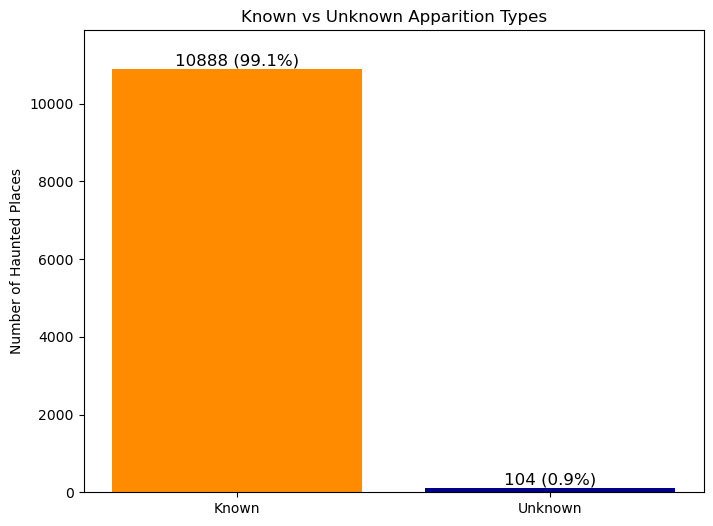

In [54]:
# Count the number of "Known" apparition types (i.e., non-Unknown)
known_count = len(haunted_places) - (haunted_places['Apparition Type'] == 'Unknown').sum()
unknown_count = (haunted_places['Apparition Type'] == 'Unknown').sum()

# Data for the bar chart
labels = ['Known', 'Unknown']
counts = [known_count, unknown_count]

# Create the bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, counts, color=['darkorange', 'darkblue'])

# Add text (count + percentage) on top of each bar
total_entries = len(haunted_places)
for bar, count in zip(bars, counts):
    percentage = (count / total_entries) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,  # Adjust the +20 for spacing
             f'{count} ({percentage:.1f}%)',
             ha='center', va='bottom', fontsize=12, color='black')  # va='bottom' places text above

# Labels and title
plt.ylabel('Number of Haunted Places')
plt.title('Known vs Unknown Apparition Types')
plt.ylim(0, max(counts) + 1000)  # Adjust buffer for text

# Show the plot
plt.show()


## Graph 2: Distribution of Apparition Types

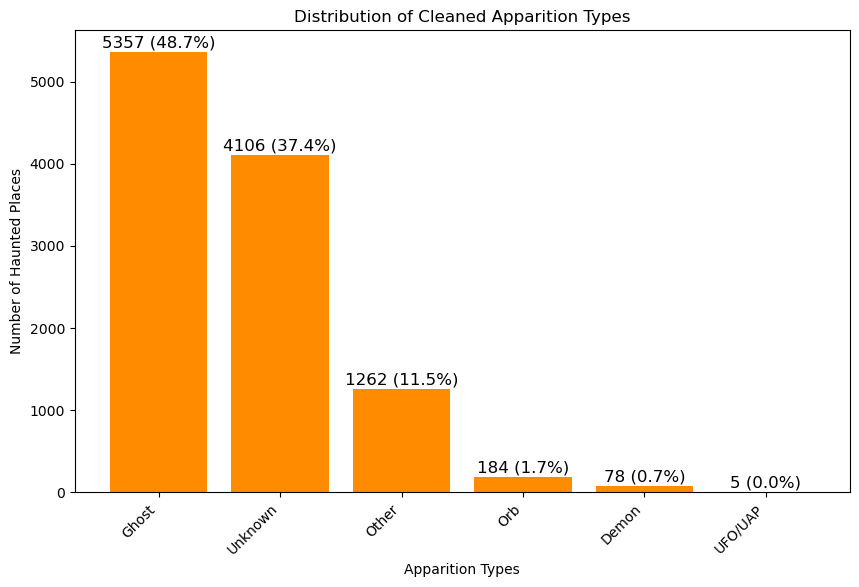

In [82]:
# Define a function to clean apparition types and group similar ones
def clean_apparition_type(apper_type):
    # Clean the apparition types by grouping similar values
    if 'Orb' in apper_type:
        return 'Orb'
    elif 'Ghost' in apper_type:
        return 'Ghost'
    elif 'Demon' in apper_type:
        return 'Demon'
    elif 'UFO' in apper_type or 'UAP' in apper_type:
        return 'UFO/UAP'
    elif 'Shadow' in apper_type:
        return 'Shadow Figure'
    elif 'Unknown' in apper_type:
        return 'Unknown'
    else:
        return 'Other'

# Apply the cleaning function to the 'Apparition Type' column
haunted_places['Cleaned Apparition Type'] = haunted_places['Apparition Type'].apply(clean_apparition_type)

# Count the number of occurrences of each cleaned Apparition Type
cleaned_apparition_counts = haunted_places['Cleaned Apparition Type'].value_counts()

# Plot the cleaned apparition type distribution
plt.figure(figsize=(10, 6))
bars = plt.bar(cleaned_apparition_counts.index, cleaned_apparition_counts.values, color='darkorange')

# Add text (count + percentage) on top of each bar
total_entries = len(haunted_places)
for bar, count in zip(bars, cleaned_apparition_counts.values):
    percentage = (count / total_entries) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20, 
             f'{count} ({percentage:.1f}%)', ha='center', va='bottom', fontsize=12, color='black')

plt.xlabel('Apparition Types')
plt.ylabel('Number of Haunted Places')
plt.title('Distribution of Apparition Types')
plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.show()


## Graph 3: Distribution of Apparition Gender

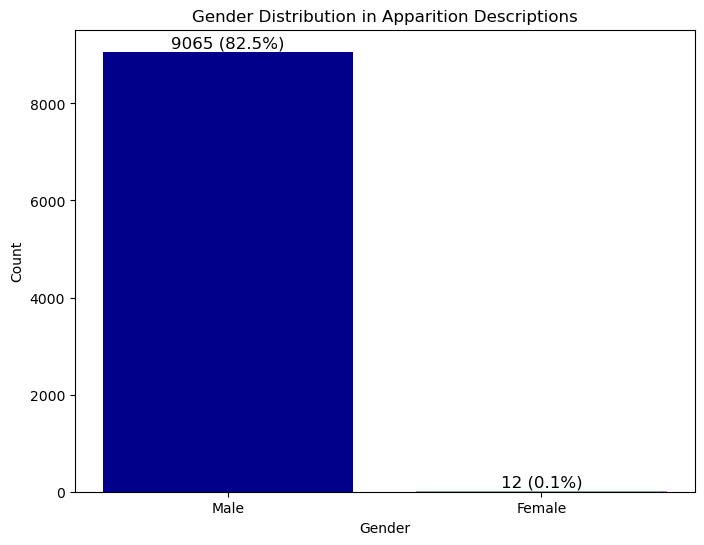

In [97]:
# Extract gender information from the 'details' column
gender_counts = haunted_places['Apparition Type'].str.extract(r'\((Male|Female)\)', expand=False)

# Count the occurrences of each gender category
gender_counts = gender_counts.value_counts()

# Plot the gender distribution
plt.figure(figsize=(8, 6))
bars = plt.bar(gender_counts.index, gender_counts.values, color=['darkblue', 'darkorange'])

# Add text (count + percentage) on top of each bar
for bar, count in zip(bars, gender_counts.values):
    percentage = (count / len(haunted_places)) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20, 
             f'{count} ({percentage:.1f}%)', ha='center', va='bottom', fontsize=12, color='black')

plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution in Apparition Descriptions')
plt.show()
